# TESS Lightkurve Tutorial: L 98-59 System
## Fixing Common Plotting Issues with Jupyter Notebooks

This notebook demonstrates how to properly access, analyze, and visualize TESS exoplanet data using Lightkurve. 
We will be examining **L 98-59**, a bright M dwarf star hosting three terrestrial-sized planets (TIC 307210830).

## 1. Import Libraries and Configure Matplotlib Backend

The key to making plots display properly in Jupyter is to use the `%matplotlib inline` magic command, 
which embeds plots directly in the notebook output. This is different from running a Python script!

**Why this matters:** In plain Python scripts, you need `plt.show()` to display plots. In Jupyter notebooks, 
`%matplotlib inline` automatically renders plots inline without requiring `plt.show()`.

In [7]:
import pip
import sys
import subprocess

try:
    import lightkurve as lk
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightkurve"])
    import lightkurve as lk

import numpy as np
from scipy import signal

%matplotlib inline
import matplotlib.pyplot as plt
import astropy.units as u

print("Libraries imported successfully!")
print(f"Lightkurve version: {lk.__version__}")
print("Matplotlib backend: ", plt.get_backend())
import numpy as np
from scipy import signal

%matplotlib inline
import matplotlib.pyplot as plt
import astropy.units as u

print("Libraries imported successfully!")
print(f"Lightkurve version: {lk.__version__}")
print("Matplotlib backend: ", plt.get_backend())

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 64.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 52.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 70.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/Users/cohen/anaconda3/envs/CV/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 2. Search and Download TESS Data Products

We'll search for three types of TESS data:
- **Full Frame Images (FFI)**: 30-min or 10-min cadence images of the full sector
- **Target Pixel Files (TPF)**: 2-min or 20-sec postage stamp cutouts centered on the star
- **Light Curve Files (LCF)**: Time-series flux measurements pre-extracted by the TESS pipeline

In [8]:
print("Searching for TESS data for L 98-59...")
print("\n1. Searching for FFI cutouts...")
search_ffi = lk.search_tesscut('L 98-59')
print(f"Found {len(search_ffi)} FFI cutout sectors")

print("\n2. Searching for Target Pixel Files (TPF)...")
search_tpf = lk.search_targetpixelfile('L 98-59')
print(f"Found {len(search_tpf)} TPF sectors")

print("\n3. Searching for Light Curve Files (LCF)...")
search_lcf = lk.search_lightcurve('L 98-59')
print(f"Found {len(search_lcf)} LCF sectors")

print("\n✓ All searches complete!")

Searching for TESS data for L 98-59...

1. Searching for FFI cutouts...
Found 28 FFI cutout sectors

2. Searching for Target Pixel Files (TPF)...
Found 68 TPF sectors

3. Searching for Light Curve Files (LCF)...
Found 138 LCF sectors

✓ All searches complete!


In [9]:
print("Downloading light curves from SPOC pipeline (2-min cadence)...")
search_lcf_refined = lk.search_lightcurve('L 98-59', author="SPOC", exptime=120)
print(f"Refined search found {len(search_lcf_refined)} SPOC light curves")

# Download all sectors at once (this may take a minute)
lcf = search_lcf_refined.download_all()
print(f"\n✓ Downloaded {len(lcf)} light curve files")
print(f"Type: {type(lcf)}")
print("\nLight curve collection summary:")
for i, lc in enumerate(lcf[:3]):  # Show first 3
    print(f"  {i}: Sector {lc.meta.get('SECTOR', '?')}, {len(lc)} cadences, author={lc.meta.get('AUTHOR', '?')}")

Refined search found 27 SPOC light curves

✓ Downloaded 27 light curve files
Type: <class 'lightkurve.collections.LightCurveCollection'>

Light curve collection summary:
  0: Sector 2, 18300 cadences, author=SPOC
  1: Sector 5, 17690 cadences, author=SPOC
  2: Sector 8, 13362 cadences, author=SPOC


## 3. Inspect Light Curve Metadata and Arrays

Before plotting, it's essential to understand your data structure. Let's examine the first light curve in detail.

In [12]:
lc = lcf[0]  # Get the first light curve (Sector 2)

print(f"Light curve from: {lc.meta.get('LABEL', 'Unknown')} - Sector {lc.meta.get('SECTOR', '?')}")
print(f"Number of cadences: {len(lc)}")
print(f"\nAvailable flux columns:")
print(f"  - sap_flux (Simple Aperture Photometry): {len(lc.sap_flux)} values")
print(f"  - pdcsap_flux (Pre-search Data Conditioning): {len(lc.pdcsap_flux)} values")
print(f"  - Default flux: {len(lc.flux)} values")

print(f"\nTime array:")
print(f"  Min time: {lc.time.min().jd:.4f} BJD")
print(f"  Max time: {lc.time.max().jd:.4f} BJD")
print(f"  Duration: {(lc.time.max() - lc.time.min()).to(u.day).value:.2f} days")
print(f"  Max time: {lc.time.max().jd:.4f} BJD")
print(f"  Duration: {lc.time.max() - lc.time.min():.2f} days")

print(f"\nFlux statistics (pdcsap_flux):")
print(f"  Mean: {np.nanmean(lc.pdcsap_flux):.2e} electrons/s")
print(f"  Std:  {np.nanstd(lc.pdcsap_flux):.2e} electrons/s")
print(f"  NaN values: {np.sum(np.isnan(lc.pdcsap_flux))} / {len(lc.pdcsap_flux)}")
print(f"  Infinite values: {np.sum(np.isinf(lc.pdcsap_flux))} / {len(lc.pdcsap_flux)}")

Light curve from: TIC 307210830 - Sector 2
Number of cadences: 18300

Available flux columns:
  - sap_flux (Simple Aperture Photometry): 18300 values
  - pdcsap_flux (Pre-search Data Conditioning): 18300 values
  - Default flux: 18300 values

Time array:
  Min time: 2458354.1074 BJD
  Max time: 2458381.5126 BJD
  Duration: 27.41 days
  Max time: 2458381.5126 BJD


TypeError: unsupported format string passed to TimeDelta.__format__

## 4. Handle NaNs and Bad Cadences Before Plotting

Bad cadences (NaN, infinite, or low-quality data) can cause plots to render incorrectly or appear empty. 
Always clean your data before plotting!

In [13]:
print("Original light curve:")
print(f"  Length: {len(lc)} cadences")
print(f"  NaN count: {np.sum(np.isnan(lc.flux))}")
print(f"  Infinite count: {np.sum(np.isinf(lc.flux))}")

# Method 1: Remove NaN and infinite values
lc_clean = lc.remove_nans()
print(f"\nAfter remove_nans():")
print(f"  Length: {len(lc_clean)} cadences (removed {len(lc) - len(lc_clean)})")
print(f"  NaN count: {np.sum(np.isnan(lc_clean.flux))}")

# Method 2: Also remove outliers (optional)
lc_clean = lc_clean.remove_outliers(sigma=5)
print(f"\nAfter remove_outliers(sigma=5):")
print(f"  Length: {len(lc_clean)} cadences")

print("\n✓ Data is now clean and ready for plotting!")

Original light curve:
  Length: 18300 cadences
  NaN count: ———
  Infinite count: —

After remove_nans():
  Length: 17578 cadences (removed 722)
  NaN count: 0

After remove_outliers(sigma=5):
  Length: 17577 cadences

✓ Data is now clean and ready for plotting!


## 5. Plot Lightkurve Objects Correctly

The `lc.plot()` method is convenient, but you must:
1. Use the correct `column` argument (e.g., 'pdcsap_flux' or 'sap_flux')
2. Capture the returned axes object if you want to overplot
3. In Jupyter, plots appear automatically without `plt.show()`

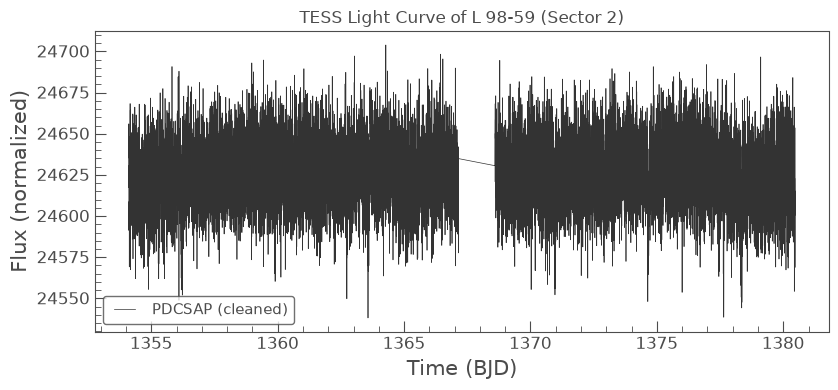

In [14]:
# Plot the cleaned PDCSAP light curve
lc_clean.plot(column='pdcsap_flux', label='PDCSAP (cleaned)')
plt.title('TESS Light Curve of L 98-59 (Sector 2)')
plt.ylabel('Flux (normalized)')
plt.xlabel('Time (BJD)')
plt.tight_layout()
# Note: No plt.show() needed in Jupyter! The plot appears automatically.

## 6. Overplot SAP and PDCSAP Light Curves

Comparing uncorrected (SAP) and corrected (PDCSAP) flux reveals how the TESS pipeline removes systematic trends.

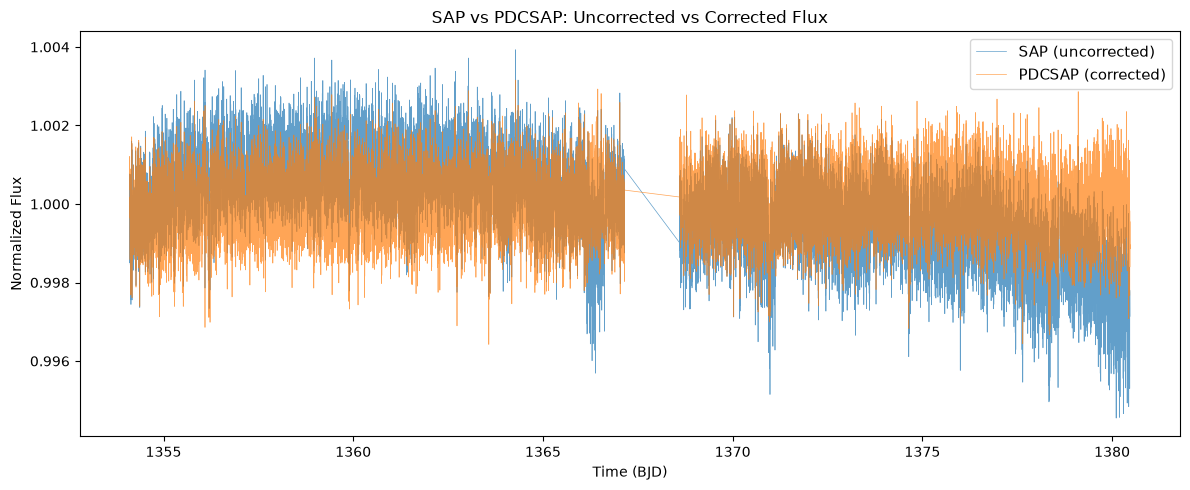

In [15]:
# Create a new figure
fig, ax = plt.subplots(figsize=(12, 5))

# Plot both SAP and PDCSAP on the same axes
ax = lc_clean.plot(column='sap_flux', normalize=True, ax=ax, label='SAP (uncorrected)', alpha=0.7)
ax = lc_clean.plot(column='pdcsap_flux', normalize=True, ax=ax, label='PDCSAP (corrected)', alpha=0.7)

ax.set_title('SAP vs PDCSAP: Uncorrected vs Corrected Flux')
ax.set_ylabel('Normalized Flux')
ax.set_xlabel('Time (BJD)')
ax.legend(loc='best', fontsize=11)
plt.tight_layout()

## 7. Build Custom Matplotlib Plots from Arrays

Sometimes Lightkurve's plotting methods don't work as expected. In those cases, plot the raw arrays directly 
using Matplotlib. This gives you full control and helps diagnose data issues.

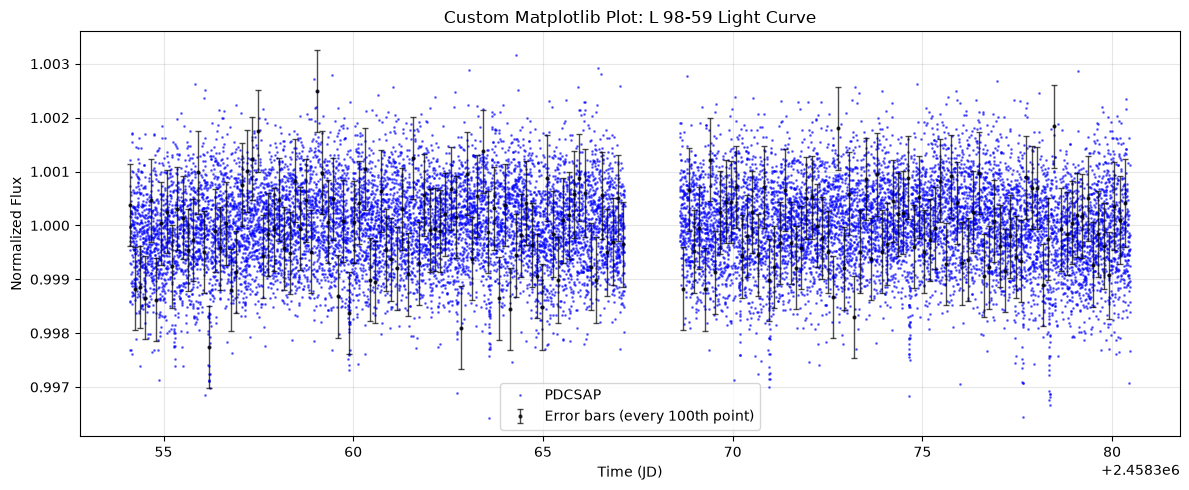

In [16]:
# Extract time and flux arrays directly
time = lc_clean.time.jd  # Convert to Julian Day
flux = lc_clean.pdcsap_flux
flux_err = lc_clean.pdcsap_flux_err

# Normalize flux
flux_norm = flux / np.nanmedian(flux)

# Create a custom plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time, flux_norm, 'b.', markersize=2, alpha=0.5, label='PDCSAP')
ax.errorbar(time[::100], flux_norm[::100], yerr=flux_err[::100]/np.nanmedian(flux), 
            fmt='k.', markersize=4, elinewidth=1, capsize=2, alpha=0.7, label='Error bars (every 100th point)')

ax.set_title('Custom Matplotlib Plot: L 98-59 Light Curve')
ax.set_xlabel('Time (JD)')
ax.set_ylabel('Normalized Flux')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()

## 8. Debug Empty or Wrong Plots with Data Checks

If your plot appears empty or shows the wrong data, run these diagnostics:

In [17]:
def diagnose_lightcurve(lc, name="Light Curve"):
    """Run diagnostic checks on a light curve."""
    print(f"=== Diagnostic Report: {name} ===")
    print(f"Length: {len(lc)} cadences")
    print(f"\nTime array:")
    print(f"  Min: {lc.time.min():.4f} BJD")
    print(f"  Max: {lc.time.max():.4f} BJD")
    print(f"  All valid? {not (np.any(np.isnan(lc.time)) or np.any(np.isinf(lc.time)))}")
    
    print(f"\nFlux array (default):")
    print(f"  Min: {np.nanmin(lc.flux):.2e}")
    print(f"  Max: {np.nanmax(lc.flux):.2e}")
    print(f"  Mean: {np.nanmean(lc.flux):.2e}")
    print(f"  NaN count: {np.sum(np.isnan(lc.flux))} ({100*np.sum(np.isnan(lc.flux))/len(lc.flux):.1f}%)")
    print(f"  Inf count: {np.sum(np.isinf(lc.flux))}")
    print(f"  All zeros? {np.all(lc.flux == 0)}")
    
    if hasattr(lc, 'quality'):
        print(f"\nQuality flags:")
        print(f"  Good cadences: {np.sum(lc.quality == 0)} / {len(lc.quality)}")
        print(f"  Bad cadences: {np.sum(lc.quality != 0)}")
    
    print(f"\n✓ Diagnostics complete\n")

# Run diagnostics on the light curve
diagnose_lightcurve(lc_clean, "Cleaned Light Curve (Sector 2)")

=== Diagnostic Report: Cleaned Light Curve (Sector 2) ===
Length: 17577 cadences

Time array:


TypeError: unsupported format string passed to Time.__format__

## 9. Extract and Plot FFI Aperture Masks and Cutouts

For objects not observed as formal targets, we can extract light curves from Full Frame Images (FFIs) using custom apertures.

In [18]:
print("Downloading FFI cutout data (this may take a minute)...")
ffi_data = search_ffi[1].download(cutout_size=10)  # Download a 10x10 pixel region
print(f"✓ Downloaded FFI cutout: {type(ffi_data)}")
print(f"  Shape: {ffi_data.data.shape} (time, pixel_row, pixel_col)")
print(f"  Time range: {ffi_data.time[0]:.2f} to {ffi_data.time[-1]:.2f} BJD")

✓ Downloaded FFI cutout: <class 'lightkurve.targetpixelfile.TessTargetPixelFile'>


AttributeError: 'TessTargetPixelFile' object has no attribute 'data'

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

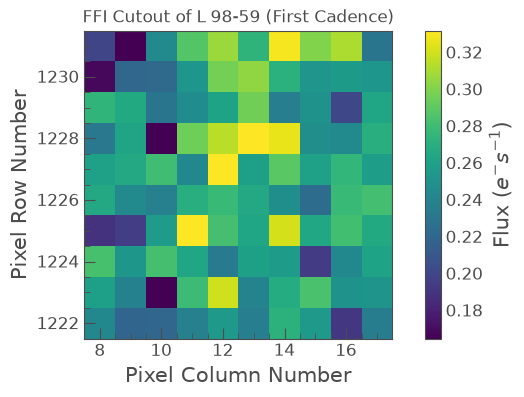

In [19]:
# Plot the FFI cutout (first cadence)
ffi_data.plot()
plt.title('FFI Cutout of L 98-59 (First Cadence)')
plt.colorbar(label='Flux (electrons/s)')

Creating aperture mask...
✓ Aperture mask created: 0 pixels selected


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

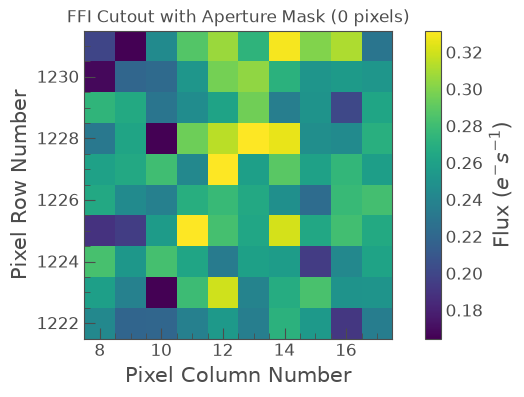

In [20]:
print("Creating aperture mask...")
# Create a threshold-based aperture mask
target_mask = ffi_data.create_threshold_mask(threshold=15, reference_pixel='center')
n_target_pixels = target_mask.sum()
print(f"✓ Aperture mask created: {n_target_pixels} pixels selected")

# Plot the aperture mask overlay
ffi_data.plot(aperture_mask=target_mask, mask_color='red')
plt.title(f'FFI Cutout with Aperture Mask ({n_target_pixels} pixels)')
plt.colorbar(label='Flux (electrons/s)')

In [ ]:
print("Extracting light curve from FFI using aperture mask...")
ffi_lc = ffi_data.to_lightcurve(aperture_mask=target_mask)
print(f"✓ FFI light curve extracted: {len(ffi_lc)} cadences")

# Plot the FFI light curve
ffi_lc.plot(label='SAP FFI')
plt.title('FFI-Extracted Light Curve of L 98-59 (Simple Aperture Photometry)')
plt.ylabel('Flux (electrons/s)')
plt.xlabel('Time (BJD)')
plt.tight_layout()

Comparing FFI-extracted light curve with SPOC pipeline light curve...


NameError: name 'ffi_lc' is not defined

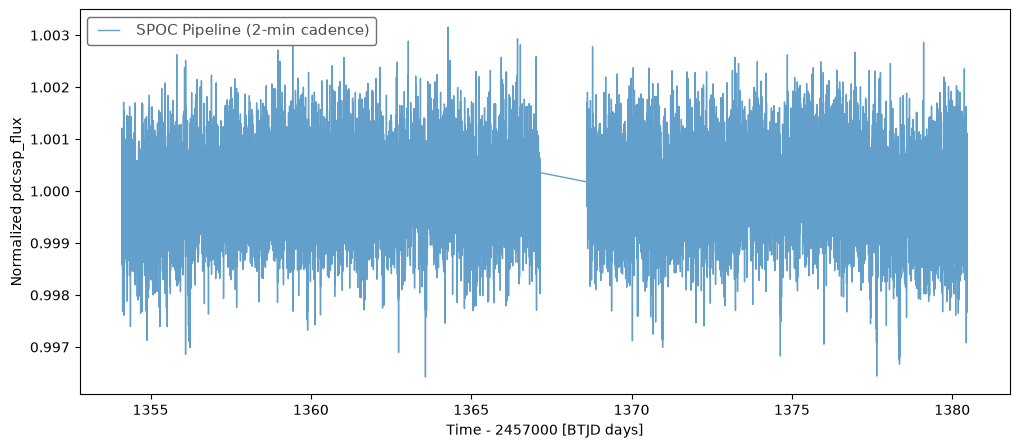

In [21]:
print("Comparing FFI-extracted light curve with SPOC pipeline light curve...")

# Compare FFI (from aperture photometry) with SPOC (from pipeline)
fig, ax = plt.subplots(figsize=(12, 5))

# Normalize both to make comparison easier
ax = lc_clean.plot(column='pdcsap_flux', normalize=True, ax=ax, 
                    label='SPOC Pipeline (2-min cadence)', alpha=0.7, linewidth=1)
ax = ffi_lc.plot(ax=ax, normalize=True, 
                 label='FFI Aperture Photometry (30-min cadence)', alpha=0.7, linewidth=2)

ax.set_title('Comparison: FFI Custom Extraction vs SPOC Pipeline Light Curves')
ax.set_ylabel('Normalized Flux')
ax.set_xlabel('Time (BJD)')
ax.legend(loc='best', fontsize=11)
plt.tight_layout()

## Summary: Why Your Plots Were Not Showing

**The Problem:** You were running code as a Python script (`.py` file), but trying to follow a Jupyter notebook tutorial.

**Key Differences:**
| Jupyter Notebook | Python Script |
|------------------|---------------|
| Plots render automatically in the cell | Requires `plt.show()` to display |
| `%matplotlib inline` enables inline rendering | Not applicable (magic commands don't work) |
| Interactive tools like `.interact()` work seamlessly | Interactive tools may not work properly |
| Code runs in cells, preserving state | All code runs at once or via explicit calls |

**Solution:** Use the Jupyter notebook provided (`TESS_Lightkurve_Tutorial.ipynb`) instead of a plain Python script!

## Next Steps

1. **Clean your data** before plotting: `remove_nans()`, `remove_outliers()`
2. **Always specify the column**: `lc.plot(column='pdcsap_flux')` 
3. **Inspect arrays before plotting**: Check for NaNs, time range, and axis limits
4. **Use custom Matplotlib plots** when Lightkurve's plotting wrapper fails
5. **Compare SAP vs PDCSAP** to understand systematic corrections
6. **Extract FFI light curves** for objects not observed as formal targets

## Additional Resources

- [Lightkurve Official Documentation](https://docs.lightkurve.org/)
- [TESS GI Resources](https://heasarc.gsfc.nasa.gov/docs/tess/)
- [MAST Archive](https://mast.stsci.edu/)